# Student marks predictor

In [1]:
# import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# load dataset 

df = pd.read_csv(r'D:\Full Stack Data Science With Gen AI & Agentic AI Notes\Notes\May\8 May\Student marks predictor deployment\Student information.csv')

In [3]:
df.head()

,study_hours,student_marks
0,6.83,78.50
1,6.56,76.74
2,NaN,78.68
3,5.67,71.82
4,8.67,84.19


In [4]:
df.tail()

,study_hours,student_marks
195,7.53,81.67
196,8.56,84.68
197,8.94,86.75
198,6.60,78.05
199,8.35,83.50


In [5]:
df.shape

(200, 2)

In [6]:
# Discover and visualize the data to gain insights

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   study_hours    195 non-null    float64
 1   student_marks  200 non-null    float64
dtypes: float64(2)
memory usage: 3.3 KB


In [7]:
df.describe()

,study_hours,student_marks
count,195.000000,200.00000
mean,6.995949,77.93375
std,1.253060,4.92570
min,5.010000,68.57000
25%,5.775000,73.38500
50%,7.120000,77.71000
75%,8.085000,82.32000
max,8.990000,86.99000


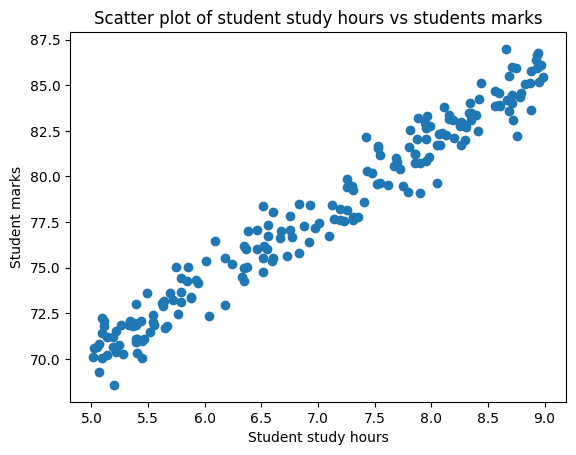

In [8]:
plt.scatter(x = df.study_hours, y = df.student_marks)
plt.xlabel('Student study hours')
plt.ylabel('Student marks')
plt.title('Scatter plot of student study hours vs students marks')
plt.show()

## Prepare the data for machine learning algorithm

In [9]:
# data cleaning

df.isnull().sum()

study_hours      5
student_marks    0
dtype: int64

In [10]:
df.mean()

study_hours       6.995949
student_marks    77.933750
dtype: float64

In [11]:
df2 = df.fillna(df.mean())

In [12]:
df2.isnull().sum()

study_hours      0
student_marks    0
dtype: int64

In [13]:
df2.head()

,study_hours,student_marks
0,6.830000,78.50
1,6.560000,76.74
2,6.995949,78.68
3,5.670000,71.82
4,8.670000,84.19


In [14]:
# Split dataset

x = df2.drop('student_marks', axis = 'columns')
y = df2.drop('study_hours', axis = 'columns')
print('Shape of x =', x.shape)
print('Shape of y =', y.shape)

Shape of x = (200, 1)
Shape of y = (200, 1)


In [15]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 0)
print('Shape of x_train =', x_train.shape)
print('Shape of x_test =', x_test.shape)
print('Shape of y_train =', y_train.shape)
print('Shape of y_test =', y_test.shape)

Shape of x_train = (160, 1)
Shape of x_test = (40, 1)
Shape of y_train = (160, 1)
Shape of y_test = (40, 1)


In [16]:
x_train

,study_hours
134,6.51
66,7.86
26,6.51
113,7.95
168,7.95
...,...
67,8.26
192,8.71
117,8.83
47,5.01


In [17]:
y_train

,student_marks
134,78.39
66,81.25
26,74.75
113,80.86
168,82.68
...,...
67,81.70
192,84.03
117,85.04
47,70.11


## Select model and train it

In [18]:
# y = mx + c

from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [19]:
lr

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [20]:
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
lr.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

In [22]:
lr.coef_

array([[3.93037294]])

In [23]:
lr.intercept_

array([50.45063632])

In [24]:
m = 3.93
c = 50.45

y = m * 4 + c
print(y)

66.17


In [25]:
import warnings
warnings.filterwarnings('ignore')

In [26]:
lr.predict([[4]])[0][0].round(2)

np.float64(66.17)

In [27]:
y_pred = lr.predict(x_test)
y_pred

array([[83.50507271],
       [70.84927186],
       [72.93236952],
       [85.35234799],
       [73.20749562],
       [84.48766595],
       [80.12495199],
       [81.85431608],
       [80.91102657],
       [82.20804964],
       [78.98514384],
       [84.84139951],
       [77.84533568],
       [77.68812077],
       [83.22994661],
       [85.78468901],
       [84.9593107 ],
       [72.61793968],
       [78.71001773],
       [79.18166248],
       [84.2911473 ],
       [85.6274741 ],
       [74.74034107],
       [81.3433676 ],
       [72.02838374],
       [80.40007809],
       [78.98514384],
       [82.09013845],
       [77.94732382],
       [82.24735337],
       [75.44780819],
       [84.60557713],
       [71.63534645],
       [75.48711192],
       [70.29901965],
       [78.98514384],
       [75.32989701],
       [84.52696967],
       [74.07217767],
       [71.4388278 ]])

In [28]:
pd.DataFrame(np.c_[x_test, y_test, y_pred], columns = ['Study_hours', 'Student_marks_original', 'Student_marks_predicted'])

,Study_hours,Student_marks_original,Student_marks_predicted
0,8.410000,82.50,83.505073
1,5.190000,71.18,70.849272
2,5.720000,73.25,72.932370
3,8.880000,83.64,85.352348
4,5.790000,73.64,73.207496
5,8.660000,86.99,84.487666
6,7.550000,81.18,80.124952
7,7.990000,82.75,81.854316
8,7.750000,79.50,80.911027
9,8.080000,81.70,82.208050


In [29]:
# Fine-tune model

lr.score(x_test, y_test)

0.9521841793508594

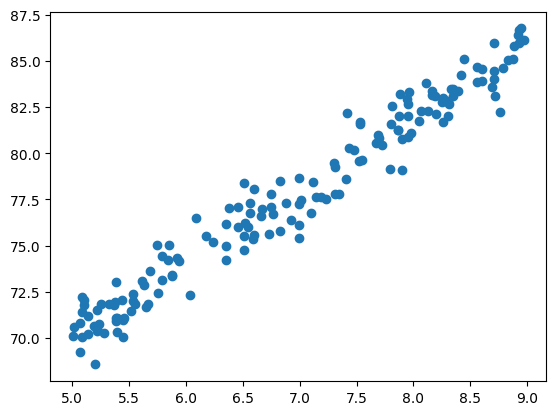

In [30]:
plt.scatter(x_train, y_train)

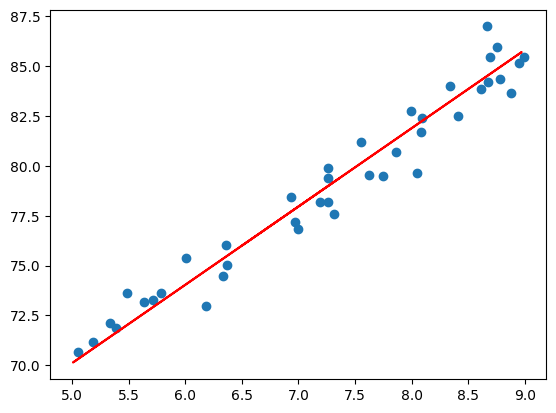

In [31]:
plt.scatter(x_test, y_test)
plt.plot(x_train, lr.predict(x_train), color = 'red')

In [32]:
# Save machine learning model

import joblib
joblib.dump(lr, 'Student_marks_predictor.pkl')

['Student_marks_predictor.pkl']

In [33]:
pwd

'C:\\Users\\dell\\Data science jupyter notebook'

In [34]:
model = joblib.load('Student_marks_predictor.pkl')

In [35]:
pwd

'C:\\Users\\dell\\Data science jupyter notebook'

In [36]:
model.predict([[5]])[0][0]

np.float64(70.10250100162845)